<a href="https://colab.research.google.com/github/KweonTJ/Machine_Learning/blob/main/5_Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np
data_loc = 'https://github.com/dknife/ML/raw/main/data/'
df = pd.read_csv(data_loc + 'two_classes.csv')
df.head(5)

,x1,x2,y
0,2.164064,-17.205938,0
1,1.947562,-32.529402,0
2,-0.860753,-18.513110,1
3,2.530348,0.693982,0
4,1.014954,47.582231,0


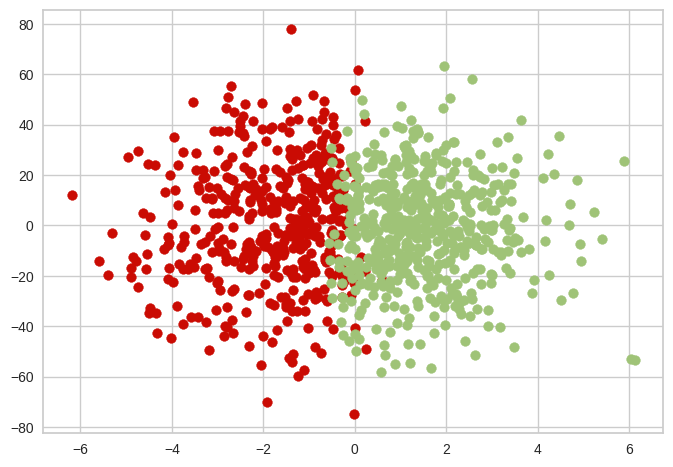

In [15]:
df_positive = df[df['y']>0]
df_negative = df[df['y']==0]
import matplotlib.pyplot as plt
plt.scatter(df_positive['x1'], df_positive['x2'], color='r')
plt.scatter(df_negative['x1'], df_negative['x2'], color='g')

In [24]:
from sklearn.svm import LinearSVC
from sklearn import set_config
set_config(print_changed_only=False)

X = df[['x1', 'x2']].to_numpy()
y = df['y']
svm_simple = LinearSVC(C=1, loss='hinge')
svm_simple.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(C=1, class_weight=None, dual='auto', fit_intercept=True,
          intercept_scaling=1, loss='hinge', max_iter=1000, multi_class='ovr',
          penalty='l2', random_state=None, tol=0.0001, verbose=0)

In [17]:
svm_simple.predict([[0.12, 0.56], [-4, 40], [0, 40], [5, 20]])

array([0, 1, 0, 0])

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


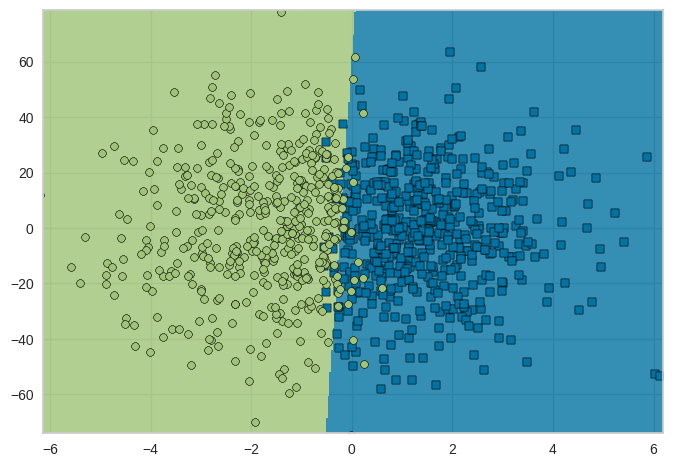

In [18]:
from yellowbrick.contrib.classifier import DecisionViz
viz = DecisionViz(svm_simple, title="linear SVM")
viz.fit(X, y)
viz.draw(X, y)

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import set_config

set_config(display='text', print_changed_only=False)

svm_std = Pipeline([
    ("std", StandardScaler()),
    ("lsvm", LinearSVC(C=1, loss='hinge'))
])
svm_std.fit(X, y)

Pipeline(memory=None,
         steps=[('std',
                 StandardScaler(copy=True, with_mean=True, with_std=True)),
                ('lsvm',
                 LinearSVC(C=1, class_weight=None, dual='auto',
                           fit_intercept=True, intercept_scaling=1,
                           loss='hinge', max_iter=1000, multi_class='ovr',
                           penalty='l2', random_state=None, tol=0.0001,
                           verbose=0))],
         transform_input=None, verbose=False)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


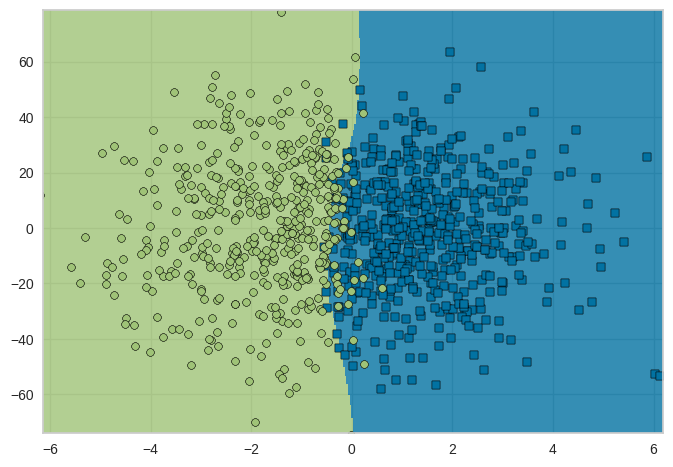

In [20]:
from sklearn.preprocessing import PolynomialFeatures
svm_poly = Pipeline([
    ("std", StandardScaler()),
    ("poly_inputs", PolynomialFeatures(degree=5)),
    ("lsvm", LinearSVC(C=0.01, loss='hinge'))
])
svm_poly.fit(X, y)
viz = DecisionViz(svm_poly, title = "polynomial feature SVM")
viz.fit(X, y)
viz.draw(X, y)